# Chapter 9: Deep Learning
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
import datetime
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
import torch.nn.functional as F
import torchvision

random.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
from pathlib import Path
DATA_DIR = Path('../../data')


## Deep Learning
### CNNs
#### Putting It All Together: An Example

In [1]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
trainset = torchvision.datasets.MNIST(root="./data", train=True,
  download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testset = torchvision.datasets.MNIST(root="./data", train=False,
  download=True, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

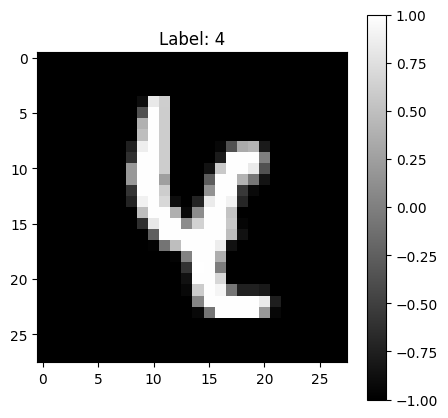

In [1]:
sample_image, label = testset[160]
image_np = sample_image.squeeze()

fig, ax = plt.subplots(figsize=(5, 5))
img = ax.imshow(image_np, cmap="gray")
fig.colorbar(img, ax=ax)
ax.set_title(f"Label: {label}")
plt.show()

In [1]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu")

model = nn.Sequential(
    # low-level feature extractor:
    # 1 channel, 32 filters, filter size 3x3, padding to keep image same size
    # conv1: 320 parameters [32x(1x3x3 + 1)]
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),  # pool1: 28x28 -> 14x14
    # mid-level feature extractor: edges -> shapes
    # conv2: 18,496 parameters [64x(32x3x3 + 1)]
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),  # pool2: 14x14 -> 7x7
    # high-level feature extractor: shapes -> objects
    # conv3: 73,856 parameters [128x(64x3x3 + 1)]
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.AdaptiveAvgPool2d(1),  # GAP: 7x7 -> 1x1
    nn.Flatten(),  # create 128 long vector
    nn.Linear(128, 10),  # 1,290 parameters [128x10 + 1]; map to 10 class scores
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [1]:
def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(dataloader)

In [1]:
@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()

    correct = 0
    total = 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [1]:
seed = 1010
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

num_epochs = 5
for epoch in range(num_epochs):
    avg_loss = train_one_epoch(model, trainloader, optimizer, criterion)
    accuracy = evaluate(model, testloader)
    print(
        f"Epoch [{epoch+1}/{num_epochs}]  "
        f"Loss: {avg_loss:.4f}  "
        f"Test Accuracy: {accuracy:.2f}%"
    )

Epoch [1/5]  Loss: 0.5420  Test Accuracy: 95.14%


Epoch [2/5]  Loss: 0.1521  Test Accuracy: 95.04%


Epoch [3/5]  Loss: 0.1075  Test Accuracy: 97.29%


Epoch [4/5]  Loss: 0.0826  Test Accuracy: 97.98%


Epoch [5/5]  Loss: 0.0668  Test Accuracy: 97.87%


In [1]:
@torch.no_grad()
def predict(model, image_tensor):
    """Run inference on a single image."""
    model.eval()

    logits = model(image_tensor.unsqueeze(0).to(device))
    probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred = int(probs.argmax())
    return pred, probs


pred, probs = predict(model, sample_image)
print(f"Predicted class: {pred}   Actual class: {label}")
print(", ".join([f"{p:.3f}" for p in probs.tolist()]))

Predicted class: 6   Actual class: 4
0.000, 0.014, 0.000, 0.000, 0.190, 0.000, 0.791, 0.000, 0.004, 0.000


### Transformers
#### Revisiting the MNIST Image Classification Example

In [1]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu")

IMG_SIZE = 28
PATCH_SIZE = 4
IN_CHANNELS = 1
NUM_CLASSES = 10 # ten digits (0-9)
EMBED_DIM = 64  # every token is a vector of 64
NUM_HEADS = 4  # number of attention heads running in parallel
NUM_LAYERS = 3 # number of transformer layers
MLP_DIM = 128
DROPOUT = 0.1 # during TRAINING randomly set 10% of values to zero

In [1]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE,
                 in_channels=IN_CHANNELS, num_classes=NUM_CLASSES,
                 embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
                 num_layers=NUM_LAYERS, mlp_dim=MLP_DIM,
                 dropout=DROPOUT):
        super().__init__()

        # ── Patch Projection ──
        self.patch_projection = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size // patch_size) ** 2
        # ── Learnable Tokens & Positional Encoding ──
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(
            torch.zeros(1, num_patches + 1, embed_dim))
        self._reset_parameters()

        self.dropout = nn.Dropout(dropout)
        # ── Transformer Encoder ──
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)
        # ── Norm Layer ──
        self.norm = nn.LayerNorm(embed_dim)
        # ── MLP Layer for Classification ──
        self.mlp_head = nn.Sequential(nn.Linear(embed_dim, mlp_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(mlp_dim, num_classes))

    def _reset_parameters(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

    def forward(self, images):
        B = images.shape[0]

        # ── Step 1–2: Extract patches and project to embed_dim
        # (B, 1, 28, 28) → (B, 64, 7, 7) → (B, 49, 64)
        x = self.patch_projection(images)  # (B, EMBED_DIM, 7, 7)
        x = x.flatten(2).transpose(1, 2)  # (B, NUM_PATCHES, EMBED_DIM)
        # ── Step 3: Prepend CLS token ──
        # (B, 49, 64) → (B, 50, 64)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        # ── Step 4: Add positional encoding
        x = x + self.pos_embedding
        x = self.dropout(x)
        # ── Step 5: Transformer encoder ──
        x = self.transformer(x)
        # ── Step 6: CLS token → MLP head ──
        cls_output = self.norm(x[:, 0])  # (B, 64)
        return self.mlp_head(cls_output)  # (B, 10)

model = VisionTransformer().to(device)

In [1]:
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):>8,}")

Total Parameters:  114,506


In [1]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

num_epochs = 5
for epoch in range(num_epochs):
    avg_loss = train_one_epoch(model, trainloader, optimizer, criterion)
    accuracy = evaluate(model, testloader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}]  "
        f"Loss: {avg_loss:.4f}  "
        f"Test Accuracy: {accuracy:.2f}%"
    )

Epoch [1/5]  Loss: 0.8533  Test Accuracy: 92.06%


Epoch [2/5]  Loss: 0.2677  Test Accuracy: 95.36%


Epoch [3/5]  Loss: 0.1886  Test Accuracy: 96.41%


Epoch [4/5]  Loss: 0.1510  Test Accuracy: 96.51%


Epoch [5/5]  Loss: 0.1296  Test Accuracy: 97.13%


In [1]:
sample_image, label = testset[160]
pred, probs = predict(model, sample_image)
print(f"Predicted class: {pred}   Actual class: {label}")
print(", ".join([f"{p:.3f}" for p in probs.tolist()]))

Predicted class: 4   Actual class: 4
0.000, 0.001, 0.000, 0.000, 0.976, 0.000, 0.005, 0.009, 0.006, 0.002


# Supplementary Material

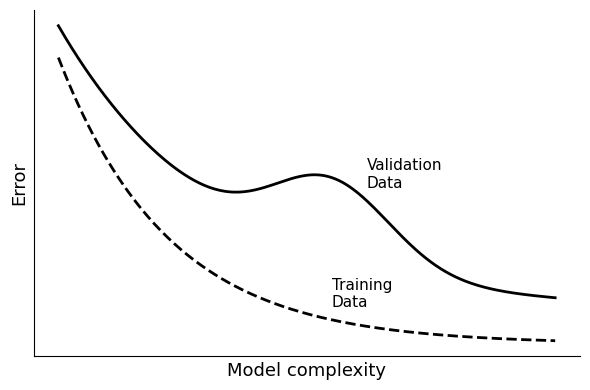

In [1]:
complexity = np.linspace(0, 100, 300)

def training_curve(x):
    return 0.9 * np.exp(-0.045 * x) + 0.05

def validation_curve(x):
    base = 0.9 * np.exp(-0.03 * x) + 0.15
    bump = 0.25 * np.exp(-((x - 55) ** 2) / (2 * 12**2))
    return base + bump

validation = validation_curve(complexity)
training = training_curve(complexity)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(complexity, training, color="black", linewidth=2, label="Training Data", ls="--")
ax.plot(complexity, validation, color="black", linewidth=2, label="Validation Data")

ax.text(62, validation_curve(62) + 0.04, "Validation\nData", fontsize=11)
ax.text(55, training_curve(55) + 0.04, "Training\nData", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("Model complexity", fontsize=13)
ax.set_ylabel("Error", fontsize=13)

plt.tight_layout()
plt.show()